<a href="https://colab.research.google.com/github/Srilatha2465/Scaler/blob/main/DSML_Portfolio_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DSML Portfolio Project - Insurance Cost Prediction:**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
!gdown https://drive.google.com/uc?id=1NBk1TFkK4NeKdodR2DxIdBp2Mk1mh4AS

Downloading...
From: https://drive.google.com/uc?id=1NBk1TFkK4NeKdodR2DxIdBp2Mk1mh4AS
To: /content/insurance.csv
100% 30.8k/30.8k [00:00<00:00, 37.8MB/s]


In [4]:
insurance = pd.read_csv('/content/insurance.csv')
insurance

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000
...,...,...,...,...,...,...,...,...,...,...,...
981,18,0,0,0,0,169,67,0,0,0,15000
982,64,1,1,0,0,153,70,0,0,3,28000
983,56,0,1,0,0,155,71,0,0,1,29000
984,47,1,1,0,0,158,73,1,0,1,39000


# 1. Problem Statement and Exploratory Data Analysis (EDA):

Insurance companies need to accurately predict the cost of health insurance for individuals to set premiums appropriately. However, traditional methods of cost prediction often rely on broad actuarial tables and historical averages, which may not account for the nuanced differences among individuals. By leveraging machine learning techniques, insurers can predict more accurately the insurance costs tailored to individual profiles, leading to more competitive pricing and better risk management.

In [5]:
#Shape of the dataset:

insurance.shape

(986, 11)

--> There are 986 rows and 11 columns in Insurance dataset.

In [6]:
#Datatypes of all attributes

insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


--> The datatype of all attributes in the Insurance dataset is 'int'. All the columns or attributes have no NULL values.

In [7]:
#Statistical Summary

insurance.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


--> The satistical summary gives meaningful information for age, height, weight and premiumprice attributes.

In [8]:
#Taking a copy of original dataset

df=insurance.copy(deep=True)
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [9]:
#Null values check

df.isnull().sum()

,0
Age,0
Diabetes,0
BloodPressureProblems,0
AnyTransplants,0
AnyChronicDiseases,0
Height,0
Weight,0
KnownAllergies,0
HistoryOfCancerInFamily,0
NumberOfMajorSurgeries,0


-->No Null values present in Insurance dataset.

In [10]:
# Conversion to Category columns:

cat_cols = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries']

for col in cat_cols:
    df[col] = df[col].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      986 non-null    int64   
 1   Diabetes                 986 non-null    category
 2   BloodPressureProblems    986 non-null    category
 3   AnyTransplants           986 non-null    category
 4   AnyChronicDiseases       986 non-null    category
 5   Height                   986 non-null    int64   
 6   Weight                   986 non-null    int64   
 7   KnownAllergies           986 non-null    category
 8   HistoryOfCancerInFamily  986 non-null    category
 9   NumberOfMajorSurgeries   986 non-null    category
 10  PremiumPrice             986 non-null    int64   
dtypes: category(7), int64(4)
memory usage: 38.6 KB


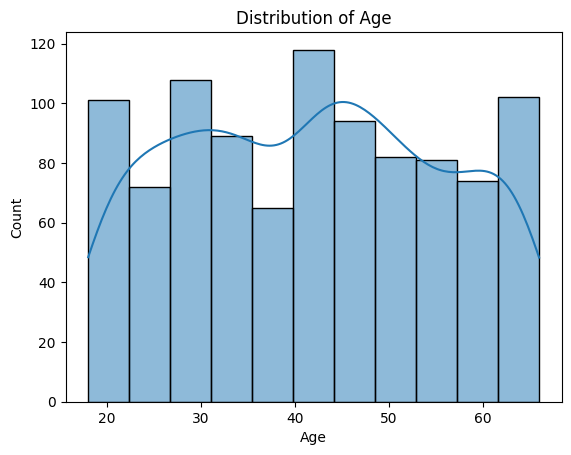

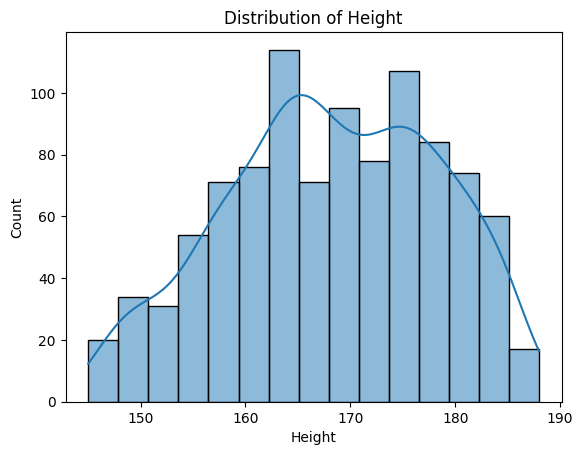

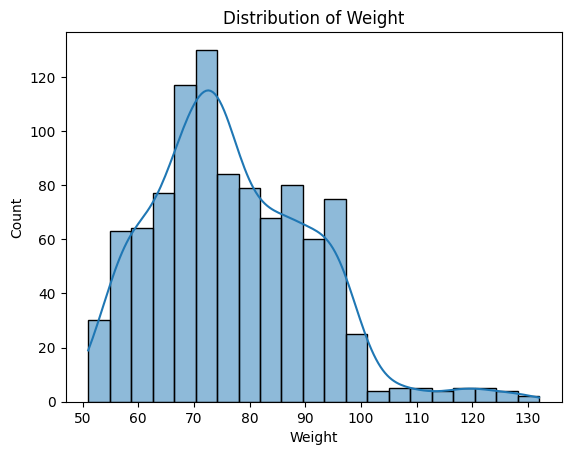

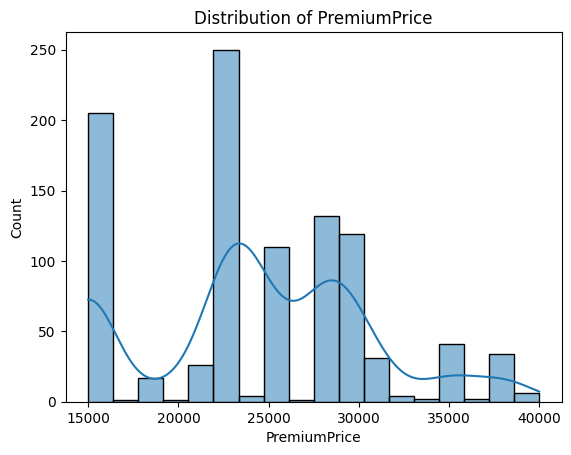

In [11]:
# Distribution Analysis

num_cols = ['Age', 'Height', 'Weight', 'PremiumPrice']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

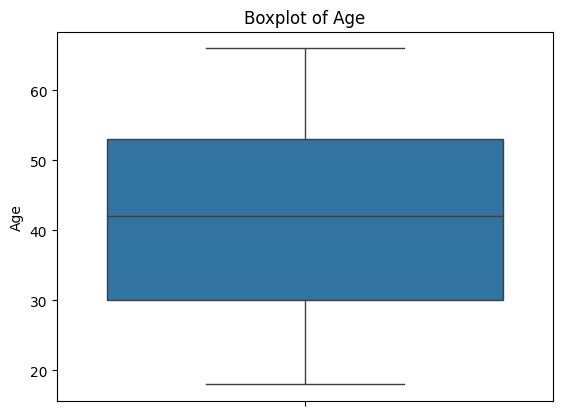

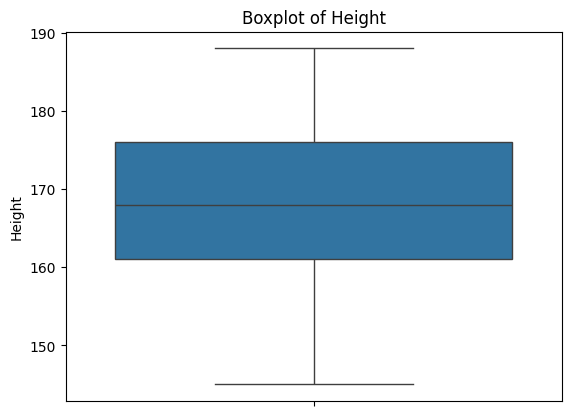

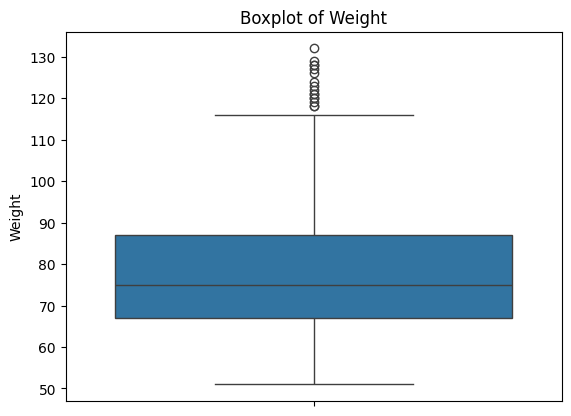

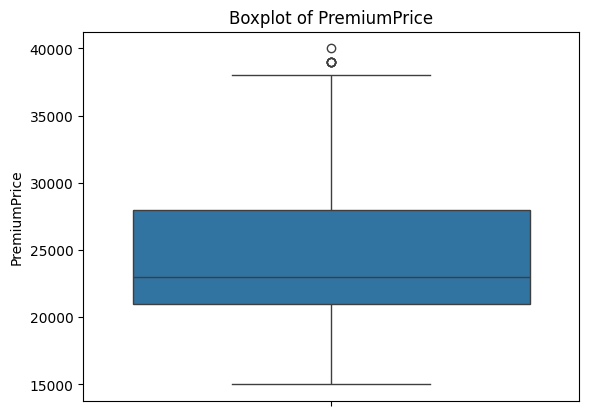

In [12]:
# Outliers Detection - Boxplots

for col in num_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

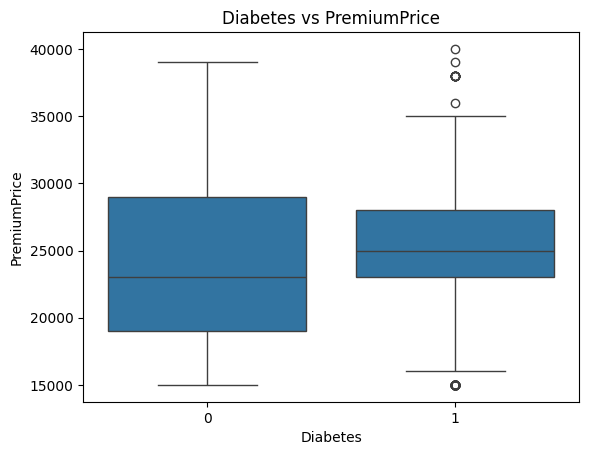

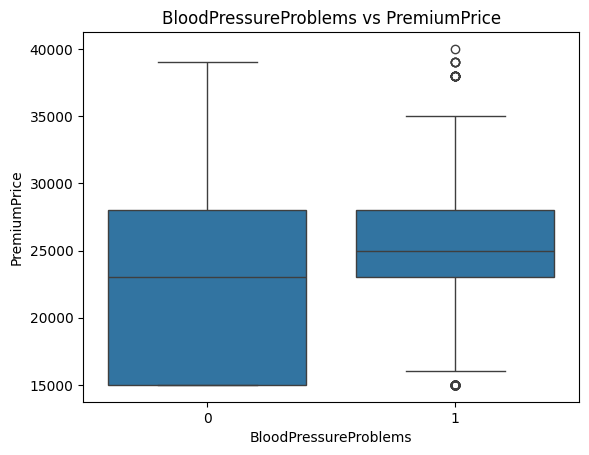

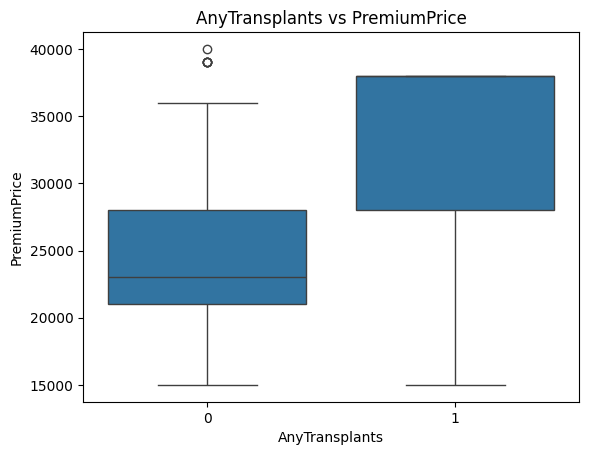

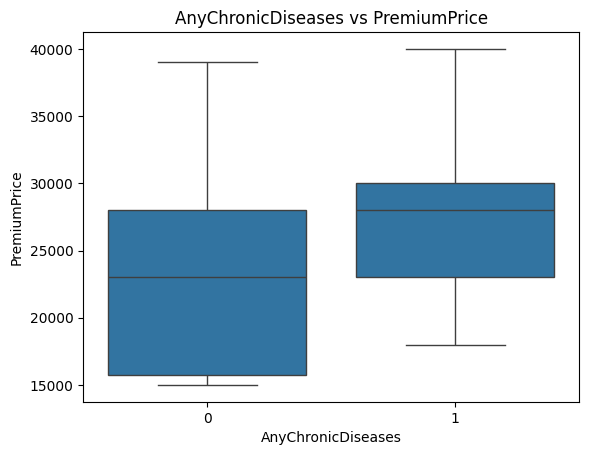

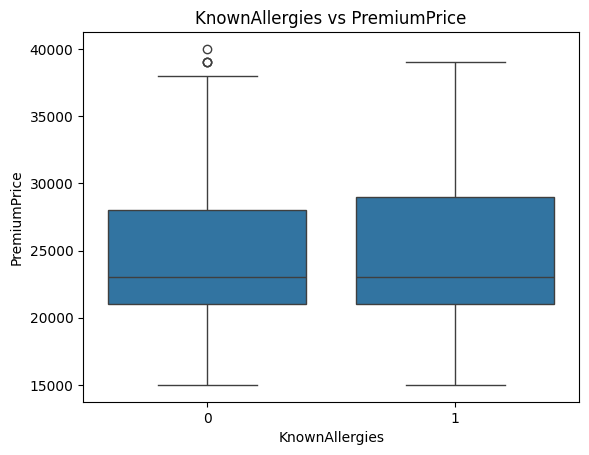

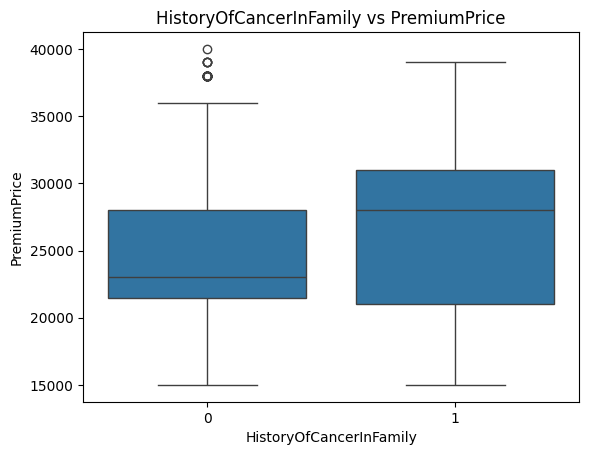

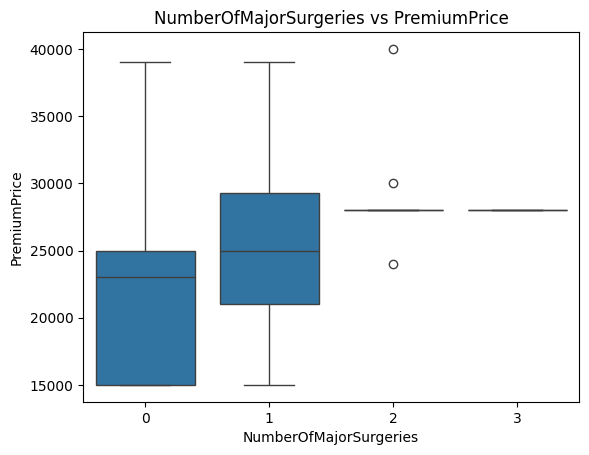

In [13]:
# Categorical vs Target (PremiumPrice)

target = 'PremiumPrice'

for col in cat_cols:
    plt.figure()
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f'{col} vs {target}')
    plt.show()

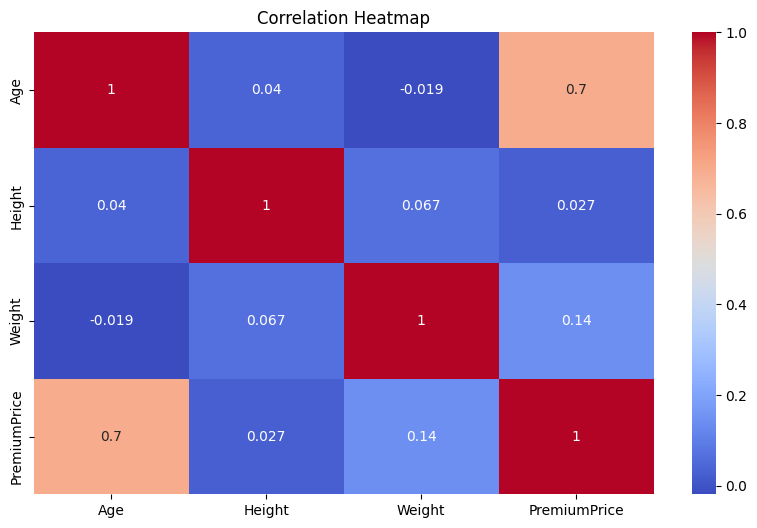

In [14]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

-->Age and PremiumPrice are highly correlated.

In [15]:
# Outlier Detection (IQR Method)

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} → {len(outliers)} outliers")

for col in num_cols:
    detect_outliers_iqr(df, col)

Age → 0 outliers
Height → 0 outliers
Weight → 16 outliers
PremiumPrice → 6 outliers


# 2. Hypothesis Testing:

**2.1: T-Test**

In [16]:
# Diabetes Impact on Premium Price - "T-Test":

# Hypothesis
# H0: No difference in the premium price
# H1: Customers with diabetes pay higher premium price

group1 = df[df['Diabetes'] == 1][target]
group2 = df[df['Diabetes'] == 0][target]

t_stat, p_value = stats.ttest_ind(group1, group2)

print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Significant difference - Customers with diabetes pay higher premium price")
else:
    print("Fail to reject H0")

P-Value: 0.01669009138530611
Reject H0 → Significant difference - Customers with diabetes pay higher premium price


**2.2: ANOVA:**

In [17]:
# Number Of Major Surgeries Impact on Premium Price - "ANOVA":

# Hypothesis:
# H0: All groups have same mean premium
# H1: At least one group differs

groups = df.groupby('NumberOfMajorSurgeries')[target].apply(list)

f_stat, p_value = stats.f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Significant difference - At least one group differs")
else:
    print("Fail to reject H0")


F-Statistic: 26.1353935974076
P-Value: 2.8711631377228097e-16
Reject H0 → Significant difference - At least one group differs


**2.3: Chi-Square Test (Categorical Relationships):**

In [18]:
# Any Chronic Diseases	vs History Of Cancer In Family

contingency_table = pd.crosstab(df['AnyChronicDiseases'], df['HistoryOfCancerInFamily'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("P-Value:", p)

P-Value: 0.8858081638149811


**2.4: Pearsons Correlation Test:**

In [19]:
corr, p_value = stats.pearsonr(df['Age'], df[target])

print("Correlation:", corr)
print("P-Value:", p_value)

Correlation: 0.6975399655058029
P-Value: 1.322507157832154e-144


# 3. Feature Engineering:

In [20]:
# create new column BMI from Geight and Weight:

df['BMI'] = df['Weight'] / (df['Height']/100)**2
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI
0,45,0,0,0,0,155,57,0,0,0,25000,23.725286
1,60,1,0,0,0,180,73,0,0,0,29000,22.530864
2,36,1,1,0,0,158,59,0,0,1,23000,23.634033
3,52,1,1,0,1,183,93,0,0,2,28000,27.770313
4,38,0,0,0,1,166,88,0,0,1,23000,31.934969


In [21]:
# Creating  Age groups:

df['Age_group'] = pd.cut(df['Age'],
                        bins=[0, 25, 40, 60, 100],
                        labels=['Young', 'Adult', 'Middle_Age', 'Senior'])

In [22]:
# Creating BMI Categories:

df['BMI_category'] = pd.cut(df['BMI'],
                           bins=[0, 18.5, 25, 30, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [23]:
# Creating Age BMI:

df['Age_BMI'] = df['Age'] * df['BMI']

In [24]:
# One-Hot Encoding (Multi-category): Still present in notebook, but removed for current execution

df = pd.get_dummies(df, columns=['Age_group', 'BMI_category'], drop_first=True)
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,Age_BMI,Age_group_Adult,Age_group_Middle_Age,Age_group_Senior,BMI_category_Normal,BMI_category_Overweight,BMI_category_Obese
0,45,0,0,0,0,155,57,0,0,0,25000,23.725286,1067.637877,False,True,False,True,False,False
1,60,1,0,0,0,180,73,0,0,0,29000,22.530864,1351.851852,False,True,False,True,False,False
2,36,1,1,0,0,158,59,0,0,1,23000,23.634033,850.825188,True,False,False,True,False,False
3,52,1,1,0,1,183,93,0,0,2,28000,27.770313,1444.056257,False,True,False,False,True,False
4,38,0,0,0,1,166,88,0,0,1,23000,31.934969,1213.528814,True,False,False,False,False,True


In [25]:
# Scaling:

scaler = StandardScaler()

num_cols = ['Age', 'BMI', 'Age_BMI']

df[num_cols] = scaler.fit_transform(df[num_cols])


In [26]:
# Log Transformation (Fix Skewness):

df['log_premiumprice'] = np.log1p(df['PremiumPrice'])

In [27]:
# Correlation-Based Selection:

corr = df.corr(numeric_only=True)['PremiumPrice'].sort_values(ascending=False)
print(corr)

PremiumPrice               1.000000
log_premiumprice           0.988618
Age                        0.697540
Age_BMI                    0.663638
Age_group_Middle_Age       0.433563
Age_group_Senior           0.273320
Weight                     0.141507
BMI                        0.103812
BMI_category_Obese         0.095734
Height                     0.026910
BMI_category_Overweight   -0.002568
BMI_category_Normal       -0.069224
Age_group_Adult           -0.200223
Name: PremiumPrice, dtype: float64


In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['PremiumPrice', 'log_premiumprice'], errors='ignore')

# Convert all columns in X to numeric types
X_numeric = X.astype(float)

vif = pd.DataFrame()
vif["feature"] = X_numeric.columns
vif["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

print(vif)

                    feature         VIF
0                       Age   31.772844
1                  Diabetes    1.866496
2     BloodPressureProblems    2.113453
3            AnyTransplants    1.072474
4        AnyChronicDiseases    1.292195
5                    Height  496.815408
6                    Weight  365.801170
7            KnownAllergies    1.324462
8   HistoryOfCancerInFamily    1.235674
9    NumberOfMajorSurgeries    2.526259
10                      BMI   25.973555
11                  Age_BMI   30.450291
12          Age_group_Adult    4.958194
13     Age_group_Middle_Age   20.801284
14         Age_group_Senior   12.479065
15      BMI_category_Normal    9.499591
16  BMI_category_Overweight   12.686379
17       BMI_category_Obese   19.045227


# 4. Regression Analysis (Statistical Testing):

In [29]:
X = df[['Age', 'BMI']]
y = df[target]

# Add constant
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           PremiumPrice   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     500.1
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          1.56e-150
Time:                        17:02:22   Log-Likelihood:                -9670.3
No. Observations:                 986   AIC:                         1.935e+04
Df Residuals:                     983   BIC:                         1.936e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.434e+04    140.236    173.541      0.0

In [30]:
# Polynomial Features:

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df[['Age', 'BMI']])

In [31]:
# Final Feature Set:

X = df.drop(columns=['PremiumPrice', 'log_premiumprice'])
y = df['log_premiumprice']  # better target

# 5. ML Modeling:


**5.1: Setup & Train-Test Split:**

In [32]:
from sklearn.model_selection import train_test_split

target = 'log_premiumprice' if 'log_premiumprice' in df.columns else 'PremiumPrice'

X = df.drop(columns=['PremiumPrice', 'log_premiumprice'], errors='ignore')
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(788, 18) (198, 18)


**5.2: Metrics:**

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 {model_name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"R²  : {r2:.4f}")

    return {"model": model_name, "rmse": rmse, "mae": mae, "r2": r2}

**5.3: Linear Regression:**

In [34]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
lr_results = evaluate_model(y_test, y_pred_lr, "Linear Regression")


📊 Linear Regression
RMSE: 0.14
MAE : 0.10
R²  : 0.7604


**5.4: Tree-Based Models:**

**5.4.1: Decision Tree:**

In [35]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_results = evaluate_model(y_test, y_pred_dt, "Decision Tree")


📊 Decision Tree
RMSE: 0.10
MAE : 0.05
R²  : 0.8773


**5.4.2: Random Forest:**

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")


📊 Random Forest
RMSE: 0.09
MAE : 0.04
R²  : 0.9031


**5.4.3: Gradient Boosting:**

In [37]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
gb_results = evaluate_model(y_test, y_pred_gb, "Gradient Boosting")


📊 Gradient Boosting
RMSE: 0.09
MAE : 0.06
R²  : 0.8917


**5.5: Neural Network:**

In [38]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Scale for NN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)
mlp_results = evaluate_model(y_test, y_pred_mlp, "Neural Network (MLP)")


📊 Neural Network (MLP)
RMSE: 0.31
MAE : 0.24
R²  : -0.1824


**5.6: Cross-Validation (k-Fold):**

In [39]:
from sklearn.model_selection import cross_val_score

def cross_validate_model(model, X, y, name):
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )

    print(f"\n🔁 {name} CV RMSE: {-scores.mean():.2f}")
    return -scores.mean()

cross_validate_model(lr, X, y, "Linear Regression")
cross_validate_model(rf, X, y, "Random Forest")
cross_validate_model(gb, X, y, "Gradient Boosting")


🔁 Linear Regression CV RMSE: 0.15

🔁 Random Forest CV RMSE: 0.11

🔁 Gradient Boosting CV RMSE: 0.12


np.float64(0.12036506224803807)

**5.7: Feature Importance:**

**5.7.1: Random Forest Importance:**

In [40]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

Age                        0.684010
Age_BMI                    0.066330
AnyTransplants             0.056767
Weight                     0.044267
AnyChronicDiseases         0.042964
BMI                        0.026891
Height                     0.025934
NumberOfMajorSurgeries     0.020500
HistoryOfCancerInFamily    0.014397
BloodPressureProblems      0.005986
dtype: float64


**5.7.2: Permutation Importance:**

In [41]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)
perm_importance = perm_importance.sort_values(ascending=False)

print(perm_importance.head(10))

Age                        0.811355
Age_BMI                    0.444502
AnyTransplants             0.131493
AnyChronicDiseases         0.106994
Weight                     0.066594
HistoryOfCancerInFamily    0.035408
BloodPressureProblems      0.019789
NumberOfMajorSurgeries     0.014952
BMI                        0.013748
BMI_category_Normal        0.001904
dtype: float64


**5.8: SHAP:**


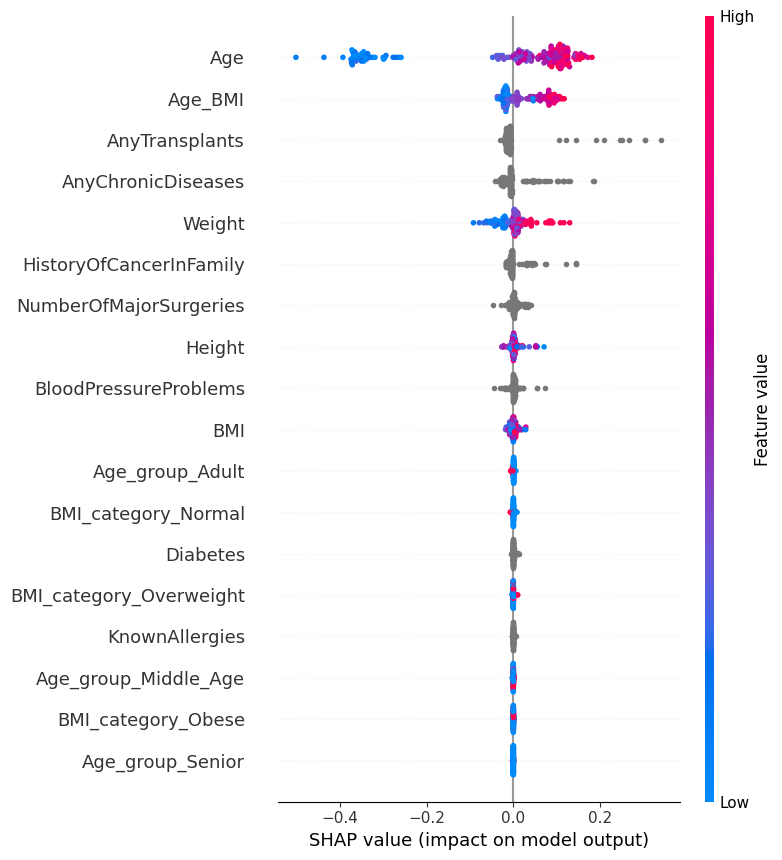

In [42]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

**5.9: Model Comparison Table:**

In [43]:
results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    gb_results,
    mlp_results
])

print(results.sort_values(by='rmse'))

                  model      rmse       mae        r2
2         Random Forest  0.087728  0.043859  0.903102
3     Gradient Boosting  0.092738  0.058563  0.891719
1         Decision Tree  0.098704  0.051923  0.877339
0     Linear Regression  0.137964  0.099262  0.760355
4  Neural Network (MLP)  0.306452  0.237183 -0.182389


After running feature importance:

- BMI and Age are strong predictors
- Risk score is a key driver
- Surgeries/chronic conditions impact pricing

**A) Key Drivers of Insurance Cost (From Model):**

High Impact Factors include:

- BMI (Obesity) → significant cost driver
- Age → steady increase in risk
- Chronic diseases / diabetes → high cost impact
- Number of surgeries → strong positive effect

**B) Actionable Business Insights:**

**1. Obesity (High BMI) → Hidden Cost Driver**

*Insight:*

Higher BMI strongly correlates with increased insurance cost.

*Business Action:*

- Introduce fitness-based discounts
- Partner with gyms / health apps
- Launch preventive health programs

*Impact:*

- Reduces future medical claims
- Encourages healthier customer base

**2. Age → Predictable Risk Increase**

*Insight:*

Premiums increase with age, especially after middle age.

*Business Action:*

- Design age-based tiered pricing
- Offer early enrollment benefits (lock lower premiums early)

*Impact:*

- Improves long-term revenue predictability
- Attracts younger customers early

**3. Chronic Diseases → High-Cost Segment**

*Insight:*

Customers with diabetes or chronic illness incur higher costs.

*Business Action:*

- Create specialized disease management plans
- Offer preventive care packages
- Use risk-based pricing

*Impact:*

- Better risk segmentation
- Reduces unexpected high claims

**4. Surgeries → Strong Cost Indicator**

*Insight:*

More surgeries → significantly higher predicted premiums.

*Business Action:*

- Introduce post-surgery recovery plans
- Offer rehabilitation support programs

*Impact:*

- Improves recovery outcomes
- Reduces repeat claims

**C) Customer Segmentation:**

Using model + features, segment customers:

**1) Low Risk**

- Normal BMI
- No chronic disease

*Strategy:*

Offer competitive low premiums

**2) Medium Risk**

- lightly overweight
- Moderate age
- Minor medical history

*Strategy:*

Preventive health engagement

**3) High Risk**

- obese
- chronic disease

*Strategy:*

- Higher premiums
- Targeted intervention programs

**D) Pricing Strategy Insights:**



From model predictions:

- Move from generic pricing → personalized pricing
- Use risk_score for dynamic pricing
- Avoid underpricing high-risk individuals

**E) Model-Based Strategic Decisions:**

**1) Product Development:**

- Launch custom insurance plans
*Example:*
- Healthy Lifestyle Plan
- Chronic Care Plan

**2) Market Expansion**

- Target young, low-risk population
- Expand in regions with lower predicted risk

**3) Marketing Strategy**

- Personalized offers using model predictions
*Example:*
- Fitness users → discounts


**F) Risk Management Insights:**

- Identify high-risk customers early
- Reduce claim volatility
- Improve loss ratio

In [52]:
df.to_csv("insurance_final.csv", index=False)